# Experiment 7 — Experiment 6 with an open-source LLM (Qwen2.5-3B) instead of FinBERT

Same intraday event study as exp 6 — **identical events, timestamps, and minute-bar
returns** — but the sentiment scorer is swapped from FinBERT to
`Qwen/Qwen2.5-3B-Instruct`, a general-purpose open-source LLM.

**Question:** does an instruction-tuned LLM (able to read context/nuance a fixed
classifier can't) find intraday post-news signal that FinBERT missed?

**Scoring:** zero-shot label-logit — prompt for positive/negative/neutral, read the
softmax over those three label tokens; signed score = p(pos) − p(neg). One forward pass
per item, so it's directly comparable to FinBERT's score.

In [1]:
# 1. Setup — load Qwen + define scorer
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from scipy import stats
from transformers import AutoTokenizer, AutoModelForCausalLM

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "experiment_7" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
import get_bars as gb

NAME = "Qwen/Qwen2.5-3B-Instruct"
tok = AutoTokenizer.from_pretrained(NAME)
tok.padding_side = "left"                      # last-token logits align across the batch
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
model = AutoModelForCausalLM.from_pretrained(NAME, dtype=torch.float16).eval()
device = "mps" if torch.backends.mps.is_available() else "cpu"
model.to(device)
LAB = {w: tok.encode(w, add_special_tokens=False)[0] for w in ["positive", "negative", "neutral"]}
LAB_IDS = [LAB["positive"], LAB["negative"], LAB["neutral"]]
print("Device:", device, "| label ids:", LAB)

/Users/georgia/Documents/Trading/sentimental_trading/trade_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Loading weights:  32%|███▏      | 137/434 [00:00<00:00, 1298.01it/s]

Loading weights:  62%|██████▏   | 267/434 [00:00<00:00, 1271.81it/s]

Loading weights:  91%|█████████ | 395/434 [00:00<00:00, 1237.59it/s]

Loading weights: 100%|██████████| 434/434 [00:00<00:00, 1265.09it/s]

Device: mps | label ids: {'positive': 30487, 'negative': 42224, 'neutral': 59568}


## 2. Load experiment 6 events (identical text + returns + FinBERT scores)

In [2]:
# 2. Reuse exp 6 events; FinBERT's column is `sentiment`
ev = pd.read_csv(REPO_ROOT / "experiment_6" / "tsla_2024_events.csv")
ev = ev.rename(columns={"sentiment": "finbert_sentiment"})
ev["t"] = pd.to_datetime(ev["t"])
ev["headline"] = ev["headline"].fillna("")
ev["summary"] = ev["summary"].fillna("")
print(f"{len(ev)} events loaded | columns incl:",
      [c for c in ev.columns if c in ("headline","summary","finbert_sentiment","session","reaction","drift_30m")])
ev[["t", "session", "headline", "finbert_sentiment"]].head(3)

4209 events loaded | columns incl: ['headline', 'summary', 'finbert_sentiment', 'session', 'reaction', 'drift_30m']


,t,session,headline,finbert_sentiment
0,2021-03-19 03:16:36,pre-market,NFT Craze A Reminder Of Tulip Mania? Keep Calm...,-0.005071
1,2021-04-08 10:02:55,regular,"Facebook Beta Tests Hotline, Its Answer To Clu...",0.268224
2,2021-06-25 12:30:26,regular,Did Billionaire Elon Musk Sell All His Mansion...,-0.571827


## 3. Score headline + summary with Qwen

In [3]:
# 3. Batched zero-shot label-logit scoring
SYS = "You are a financial sentiment classifier for stock news."
def build_prompt(text):
    msg = [{"role": "system", "content": SYS},
           {"role": "user", "content":
            f'Classify how this Tesla (TSLA) news is likely to affect the stock price. '
            f'Answer with one word: positive, negative, or neutral.\n\nNews: "{text}"\n\nAnswer:'}]
    return tok.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)

@torch.no_grad()
def qwen_scores(texts, batch_size=16):
    out = []
    n = len(texts)
    for i in range(0, n, batch_size):
        prompts = [build_prompt(t) for t in texts[i:i + batch_size]]
        enc = tok(prompts, return_tensors="pt", padding=True).to(device)
        logits = model(**enc).logits[:, -1, :]          # last token (left-padded)
        p = F.softmax(logits[:, LAB_IDS], dim=-1)         # [B,3] over pos/neg/neu
        out.extend((p[:, 0] - p[:, 1]).cpu().tolist())
        if (i // batch_size) % 20 == 0:
            print(f"  {min(i + batch_size, n):,}/{n:,}", end="\r")
    return out

text = (ev["headline"] + ". " + ev["summary"]).str.slice(0, 500)
ev["qwen_sentiment"] = qwen_scores(text.tolist())
ev.to_csv("tsla_2024_llm_events.csv", index=False)
print("\nqwen range:", round(ev["qwen_sentiment"].min(), 3), "to", round(ev["qwen_sentiment"].max(), 3),
      "| pos:", int((ev["qwen_sentiment"] > 0.05).sum()),
      "neg:", int((ev["qwen_sentiment"] < -0.05).sum()),
      "neu:", int((ev["qwen_sentiment"].abs() <= 0.05).sum()))


qwen range: -1.0 to 1.0 | pos: 1562 neg: 1569 neu: 1078


## 4. Metrics — Qwen vs FinBERT against the identical returns

In [4]:
# 4. IC / long-short spread / hit-rate for both models
def block(d, scol, rcol):
    m = d[scol].notna() & d[rcol].notna() & (d[scol] != 0)
    x, y = d.loc[m, scol], d.loc[m, rcol]
    if m.sum() < 20:
        return dict(n=int(m.sum()), ic=np.nan, ic_p=np.nan, ls_bps=np.nan, hit=np.nan)
    ic, icp = stats.spearmanr(x, y)
    return dict(n=int(m.sum()), ic=round(ic, 4), ic_p=round(icp, 4),
                ls_bps=round((y[x > 0].mean() - y[x < 0].mean()) * 1e4, 2),
                hit=round(float((np.sign(x) == np.sign(y)).mean()), 4))

WINDOWS = [("reaction [t,+1m]", "reaction"), ("drift [1m,5m]", "drift_5m"),
           ("drift [1m,15m]", "drift_15m"), ("drift [1m,30m]", "drift_30m"),
           ("drift [1m,60m]", "drift_60m")]
reg = ev[ev["session"] == "regular"]
rows = []
for label, rcol in WINDOWS:
    for mname, scol in [("Qwen-3B", "qwen_sentiment"), ("FinBERT", "finbert_sentiment")]:
        rows.append({"window": label, "model": mname, **block(reg, scol, rcol)})
cmp = pd.DataFrame(rows)
cmp.to_csv("tsla_2024_llm_vs_finbert.csv", index=False)
print("Regular-hours events:", len(reg))
cmp

Regular-hours events: 1641


,window,model,n,ic,ic_p,ls_bps,hit
0,"reaction [t,+1m]",Qwen-3B,1494,-0.0506,0.0504,-1.82,0.4679
1,"reaction [t,+1m]",FinBERT,1495,-0.0370,0.1525,-1.62,0.4910
2,"drift [1m,5m]",Qwen-3B,1494,0.0312,0.2284,1.59,0.5194
3,"drift [1m,5m]",FinBERT,1495,-0.0005,0.9849,0.24,0.4983
4,"drift [1m,15m]",Qwen-3B,1494,0.0312,0.2276,1.11,0.5120
5,"drift [1m,15m]",FinBERT,1495,0.0055,0.8304,-0.68,0.5157
6,"drift [1m,30m]",Qwen-3B,1494,0.0155,0.5483,-2.44,0.5033
7,"drift [1m,30m]",FinBERT,1495,0.0264,0.3068,-0.53,0.5057
8,"drift [1m,60m]",Qwen-3B,1494,0.0294,0.2554,4.41,0.5100
9,"drift [1m,60m]",FinBERT,1495,0.0027,0.9169,0.32,0.4997


## 5. Do the two models even agree?

Spearman(qwen, finbert) = 0.595
Sign agreement          = 75.1%


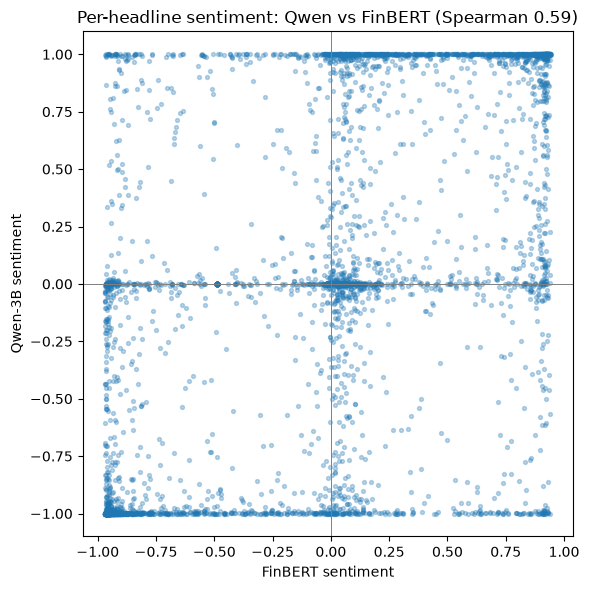

In [5]:
# 5. Agreement between Qwen and FinBERT
m = ev["qwen_sentiment"].notna() & ev["finbert_sentiment"].notna()
r = ev.loc[m, ["qwen_sentiment", "finbert_sentiment"]].corr(method="spearman").iloc[0, 1]
sign_agree = (np.sign(ev.loc[m, "qwen_sentiment"]) == np.sign(ev.loc[m, "finbert_sentiment"])).mean()
print(f"Spearman(qwen, finbert) = {r:.3f}")
print(f"Sign agreement          = {sign_agree:.1%}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ev["finbert_sentiment"], ev["qwen_sentiment"], s=8, alpha=0.3)
ax.axhline(0, color="gray", lw=0.7); ax.axvline(0, color="gray", lw=0.7)
ax.set_xlabel("FinBERT sentiment"); ax.set_ylabel("Qwen-3B sentiment")
ax.set_title(f"Per-headline sentiment: Qwen vs FinBERT (Spearman {r:.2f})")
plt.tight_layout(); plt.show()

## 6. Event-study CAR plot (Qwen sentiment, regular hours)

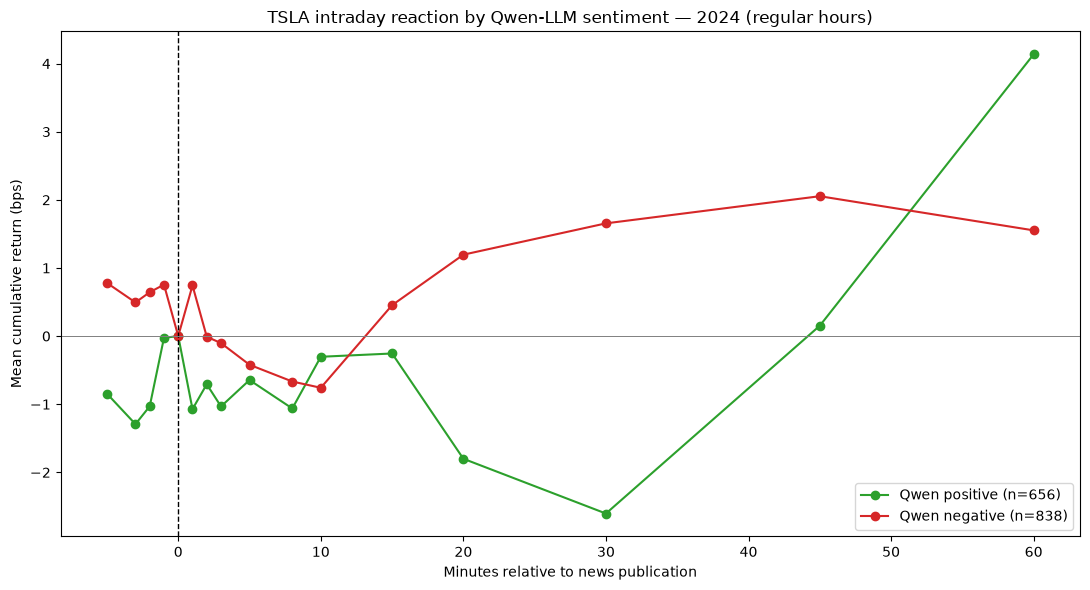

In [6]:
# 6. Refetch minute bars, plot mean cumulative return path by Qwen sentiment sign
START, END, ET = "2024-01-01T00:00:00Z", "2025-01-01T00:00:00Z", "America/New_York"
def fetch_min(feed):
    return list(gb.get_bars({"timeframe": "1Min", "start": START, "end": END, "limit": 10000,
                             "adjustment": "raw", "feed": feed, "sort": "asc"}))
try:
    mb = fetch_min("sip")
except Exception:
    mb = fetch_min("iex")
px = pd.DataFrame(mb)[["t", "c"]]
px["t"] = pd.to_datetime(px["t"], utc=True).dt.tz_convert(ET).dt.tz_localize(None)
px = px.sort_values("t").reset_index(drop=True)
pxk = px.rename(columns={"t": "key", "c": "px"})

def price_at(times, tol):
    left = pd.DataFrame({"key": pd.to_datetime(times).values})
    return pd.merge_asof(left, pxk, on="key", direction="forward",
                         tolerance=pd.Timedelta(tol))["px"].values

g = ev[(ev["session"] == "regular") & ev["entry_px"].notna() & (ev["qwen_sentiment"] != 0)].sort_values("t")
base = g["entry_px"].values
offs = [-5, -3, -2, -1, 0, 1, 2, 3, 5, 8, 10, 15, 20, 30, 45, 60]
car = {m: price_at(g["t"] + pd.Timedelta(f"{m}min"), "3min") / base - 1 for m in offs}
car = pd.DataFrame(car, index=g.index)
pos, neg = g["qwen_sentiment"] > 0, g["qwen_sentiment"] < 0

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(offs, [car.loc[pos, m].mean() * 1e4 for m in offs], "-o", color="tab:green",
        label=f"Qwen positive (n={int(pos.sum())})")
ax.plot(offs, [car.loc[neg, m].mean() * 1e4 for m in offs], "-o", color="tab:red",
        label=f"Qwen negative (n={int(neg.sum())})")
ax.axvline(0, color="black", lw=1, ls="--"); ax.axhline(0, color="gray", lw=0.7)
ax.set_xlabel("Minutes relative to news publication"); ax.set_ylabel("Mean cumulative return (bps)")
ax.set_title("TSLA intraday reaction by Qwen-LLM sentiment — 2024 (regular hours)")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Verdict — did the LLM beat FinBERT?

In [7]:
# 7. Head-to-head verdict
def get(model_name, window):
    r = cmp[(cmp["model"] == model_name) & (cmp["window"] == window)]
    return r.iloc[0]

print("Did Qwen-3B find intraday signal FinBERT missed?  (regular hours, Spearman IC)")
print("=" * 78)
print(f"{'window':<20}{'Qwen IC':>12}{'(p)':>10}{'FinBERT IC':>14}{'(p)':>10}")
print("-" * 78)
for label, _ in WINDOWS:
    q, f = get("Qwen-3B", label), get("FinBERT", label)
    print(f"{label:<20}{q['ic']:>+12.3f}{q['ic_p']:>10.3f}{f['ic']:>+14.3f}{f['ic_p']:>10.3f}")

qd = get("Qwen-3B", "drift [1m,30m]")
better = abs(qd["ic"]) > abs(get("FinBERT", "drift [1m,30m]")["ic"])
sig = qd["ic_p"] < 0.05 and qd["ic"] > 0
print("\n" + "=" * 78)
if sig:
    verdict = "Qwen finds SIGNIFICANT positive 30m drift — worth a costed backtest"
elif better:
    verdict = "Qwen's 30m drift IC is larger than FinBERT's but still NOT significant"
else:
    verdict = "NOT SUPPORTED — the LLM finds no tradeable drift either; same null as FinBERT"
print("VERDICT:", verdict)
print(f"L/S 30m drift spread: Qwen {qd['ls_bps']:+.1f} bps, FinBERT {get('FinBERT','drift [1m,30m]')['ls_bps']:+.1f} bps"
      "  (before spread/fees)")
print("Saved -> tsla_2024_llm_events.csv, tsla_2024_llm_vs_finbert.csv")

Did Qwen-3B find intraday signal FinBERT missed?  (regular hours, Spearman IC)
window                   Qwen IC       (p)    FinBERT IC       (p)
------------------------------------------------------------------------------
reaction [t,+1m]          -0.051     0.050        -0.037     0.152
drift ,5m]             +0.031     0.228        -0.001     0.985
drift ,15m]            +0.031     0.228        +0.005     0.830
drift ,30m]            +0.015     0.548        +0.026     0.307
drift ,60m]            +0.029     0.255        +0.003     0.917

VERDICT: NOT SUPPORTED — the LLM finds no tradeable drift either; same null as FinBERT
L/S 30m drift spread: Qwen -2.4 bps, FinBERT -0.5 bps  (before spread/fees)
Saved -> tsla_2024_llm_events.csv, tsla_2024_llm_vs_finbert.csv


### Reading this

- If Qwen's drift IC is ~0 like FinBERT's, the null is **model-independent**: the absence
  of intraday post-news signal isn't a weakness of a small finance classifier — a capable
  general LLM can't find it either.
- The **agreement** plot matters: if Qwen and FinBERT disagree substantially yet *both*
  give ~0 drift IC, that's strong evidence there's simply no directional signal to extract
  from headlines at this horizon.
- Any positive drift IC still has to clear TSLA's bid-ask + fees (this is gross) before it
  is real alpha.